# Mimic-Video: boundary report (fixed init, multi-seed)

Повтор эксперимента из `ysda_world_models.ipynb` (глава **Финальный отчет**), но для **mimic-video** на задаче:

- **task**: `pick up the bowl between the plate and the ramekin and place it on the plate`
- **task_id**: `0`
- **init_state / episode_idx**: `9` (как в `episode2_success` из train70)

Идея: один и тот же `task_id + episode_idx`, разные `rollout_seed` → success/fail boundary → сбор chunk-метрик → графики success vs fail.

In [5]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
# Только analysis-модули: без eval/libero/run.py (тянет cosmos_predict2).
sys.path.insert(0, str(REPO_ROOT / "scripts" / "analysis"))

# --- experiment config ---
TASK_ID = 0
EPISODE_IDX = 9  # init_state id for episode2_success
TASK_SUITE = "libero_spatial"
NUM_ROLLOUTS = 40          # как в ysda final report; для smoke поставь 4
SEED_BASE = 50_000
SEED_STRIDE = 97
MAX_CONTROL_STEPS = 220
REGEN_STRATEGY = "none"      # baseline stochastic policy

GPUS = [3, 4, 6]
WORLD_SIZE = len(GPUS)

RUN_NAME = f"task{TASK_ID}_init{EPISODE_IDX}_baseline_{NUM_ROLLOUTS}rollouts"
OUT_DIR = REPO_ROOT / "eval_outputs" / "libero_spatial" / "boundary_runs" / RUN_NAME
METRICS_DIR = OUT_DIR / "metrics"
ANALYSIS_DIR = METRICS_DIR / "analysis"

CATBOOST_OUT = REPO_ROOT / "eval_outputs/libero_spatial/boundary_runs/task0_init9_catboost_select3_6sec"
CATBOOST_METRICS = CATBOOST_OUT / "metrics"
CATBOOST_ANALYSIS = CATBOOST_METRICS / "analysis"
COMPARE_ANALYSIS = CATBOOST_METRICS / "comparison"
CATBOOST_ARTIFACTS = REPO_ROOT / "artifacts/libero_spatial/boundary_task0_init9"

T5_EMB = Path(
    "/home/motovilovil/.cache/huggingface/hub/models--nvidia--Cosmos-Policy-LIBERO-Predict2-2B/snapshots/cb689ec0e3347c13667d70a78a3447388f5c3bb8/libero_t5_embeddings.pkl"
)

print("REPO_ROOT:", REPO_ROOT)
print("OUT_DIR:", OUT_DIR)

REPO_ROOT: /home/motovilovil/Robotics/robotics_project/mimic-video
OUT_DIR: /home/motovilovil/Robotics/robotics_project/mimic-video/eval_outputs/libero_spatial/boundary_runs/task0_init9_baseline_40rollouts


## 1. Multi-seed rollout (fixed init) — **не запускать при анализе**

Прогон модели уже выполнен. Ячейку ниже пропускай, если `metrics/rank*/episode_traces.jsonl` или merged `metrics/episode_traces.jsonl` уже есть.

In [ ]:
# SKIP: прогон модели (оставлено для справки).
RUN_MODEL = False

if RUN_MODEL:
    import subprocess

    SESSION = f"mimic_boundary_task{TASK_ID}_init{EPISODE_IDX}"
    launch_env = {
        **os.environ,
        "OUT_DIR": str(OUT_DIR.relative_to(REPO_ROOT)),
        "NUM_ROLLOUTS": str(NUM_ROLLOUTS),
        "WORLD_SIZE": str(WORLD_SIZE),
        "SESSION": SESSION,
    }
    subprocess.run(
        ["bash", str(REPO_ROOT / "scripts/eval/launch_boundary_3gpu.sh")],
        check=True,
        cwd=str(REPO_ROOT),
        env=launch_env,
    )
else:
    merged = METRICS_DIR / "episode_traces.jsonl"
    rank_dirs = list(METRICS_DIR.glob("rank[0-9]*"))
    print("Пропуск прогона модели.")
    print("merged traces:", merged.exists(), merged)
    print("rank dirs:", len(rank_dirs))

## 2. Анализ и графики (как в ysda final report)

Строим:
1. query-level timeseries (success vs fail)
2. post-chunk / drift metrics
3. episode-level boxplots top separators
4. online AUC by query prefix
5. risk score histograms

In [6]:
from boundary_report import merge_rank_metrics, run_full_analysis

# Слить rank0/1/2 -> metrics/episode_traces.jsonl
if list(METRICS_DIR.glob("rank[0-9]*")):
    merge_rank_metrics(METRICS_DIR, world_size=WORLD_SIZE)

results = run_full_analysis(METRICS_DIR, ANALYSIS_DIR)
summary = results["summary"]
ranked = results["ranked"]
risk_eval = results["risk_eval"]

display(Markdown("### Outcome summary"))
display(pd.DataFrame([summary]))

display(Markdown("### Top episode-level predictors"))
display(ranked.head(12))

display(Markdown("### Handcrafted risk scores"))
display(risk_eval)

### Outcome summary

,num_rollouts,num_success,num_fail,max_chunk_id_common,success_rate
0,40,20,20,12,0.5


### Top episode-level predictors

,feature,oriented_auc,direction,best_balanced_accuracy,fail_mean,success_mean
1,action_entropy__std,0.8425,higher->fail,0.800,0.003620,0.002998
4,action_entropy__last3_mean,0.8125,lower->fail,0.775,0.909210,0.911063
3,action_entropy__last,0.8000,lower->fail,0.775,0.905486,0.908264
19,chunk_action_variance__last3_mean,0.7600,lower->fail,0.750,0.222850,0.226056
16,chunk_action_variance__std,0.7500,higher->fail,0.750,0.019140,0.018093
28,chunk_action_delta_norm_max__last,0.7400,lower->fail,0.750,0.411846,0.446186
54,video_latent_entropy__last3_mean,0.7350,lower->fail,0.700,0.990670,0.990809
64,video_latent_delta_l2_std__last3_mean,0.7325,higher->fail,0.725,29.739248,29.508482
23,chunk_action_delta_norm_mean__last,0.7300,lower->fail,0.725,0.124815,0.139768
0,action_entropy__mean,0.7225,lower->fail,0.750,0.913031,0.913411


### Handcrafted risk scores

,score,auc,direction,balanced_accuracy,threshold
0,risk_high_uncertainty,0.5425,lower->fail,0.625,-1.709650
1,risk_overconfidence_latent,0.6500,lower->fail,0.625,33.579123
2,risk_overconfidence_action,0.6100,higher->fail,0.650,-0.937390


### Query-level uncertainty metrics

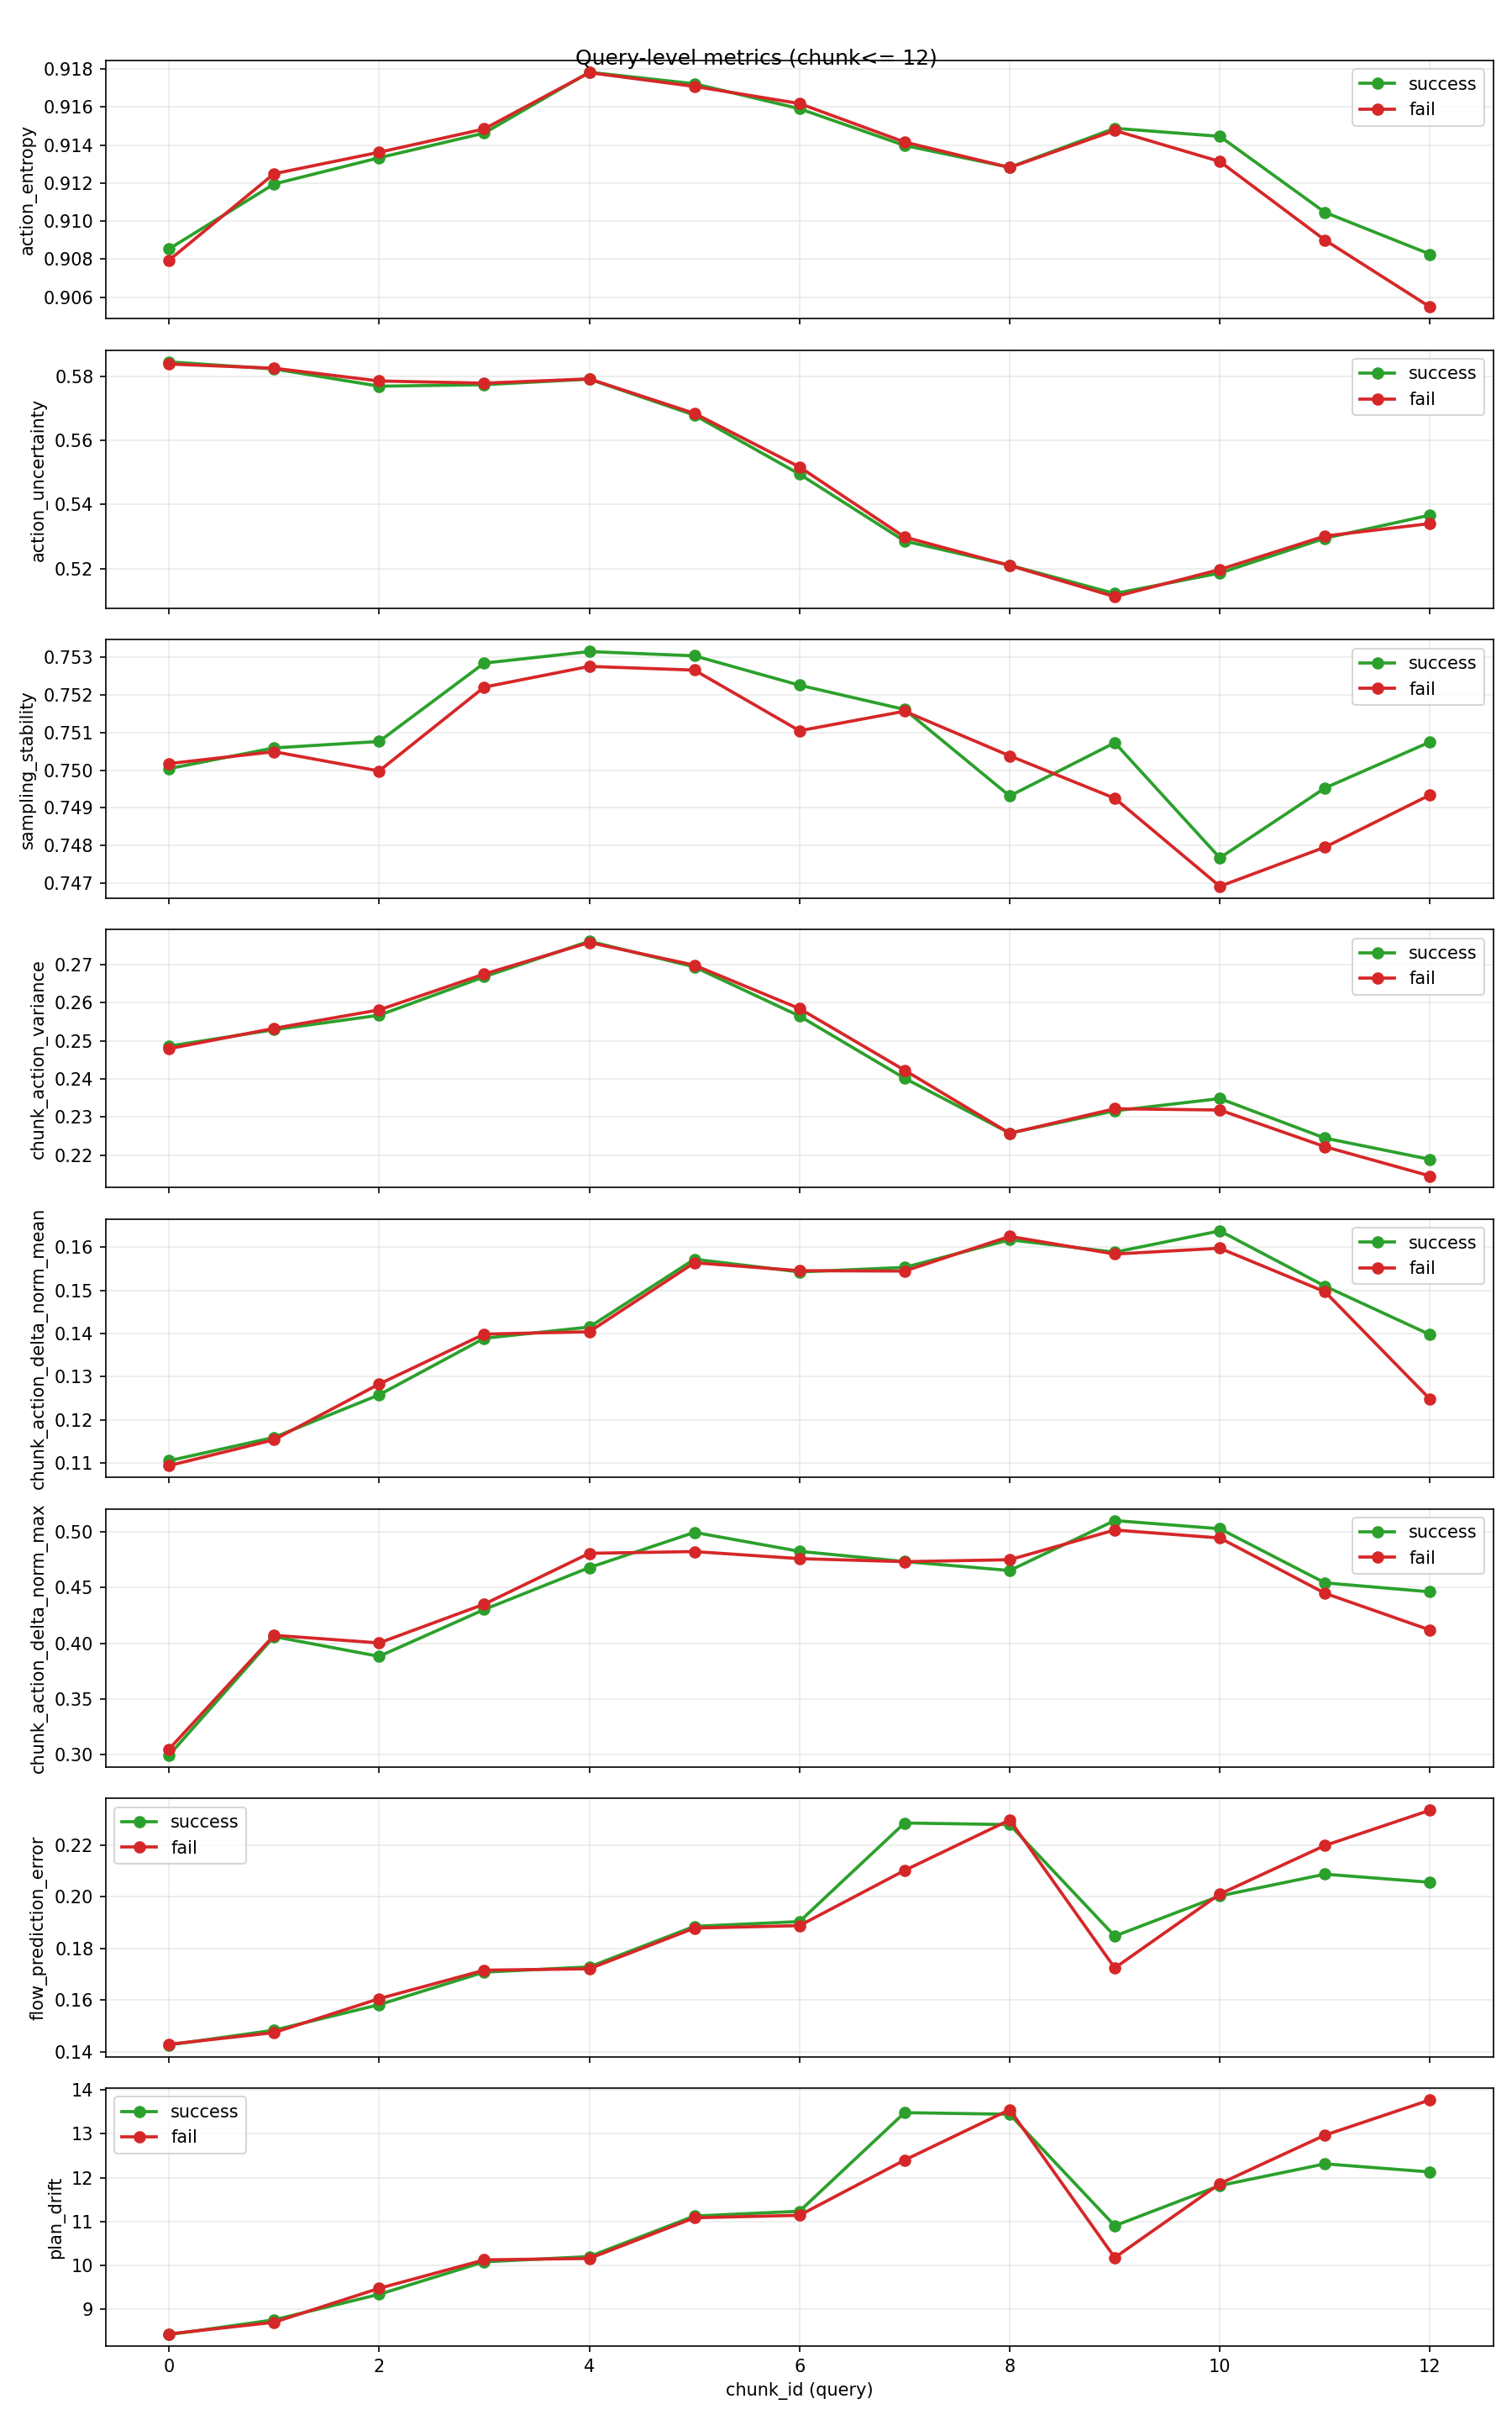

### Post-chunk / drift metrics

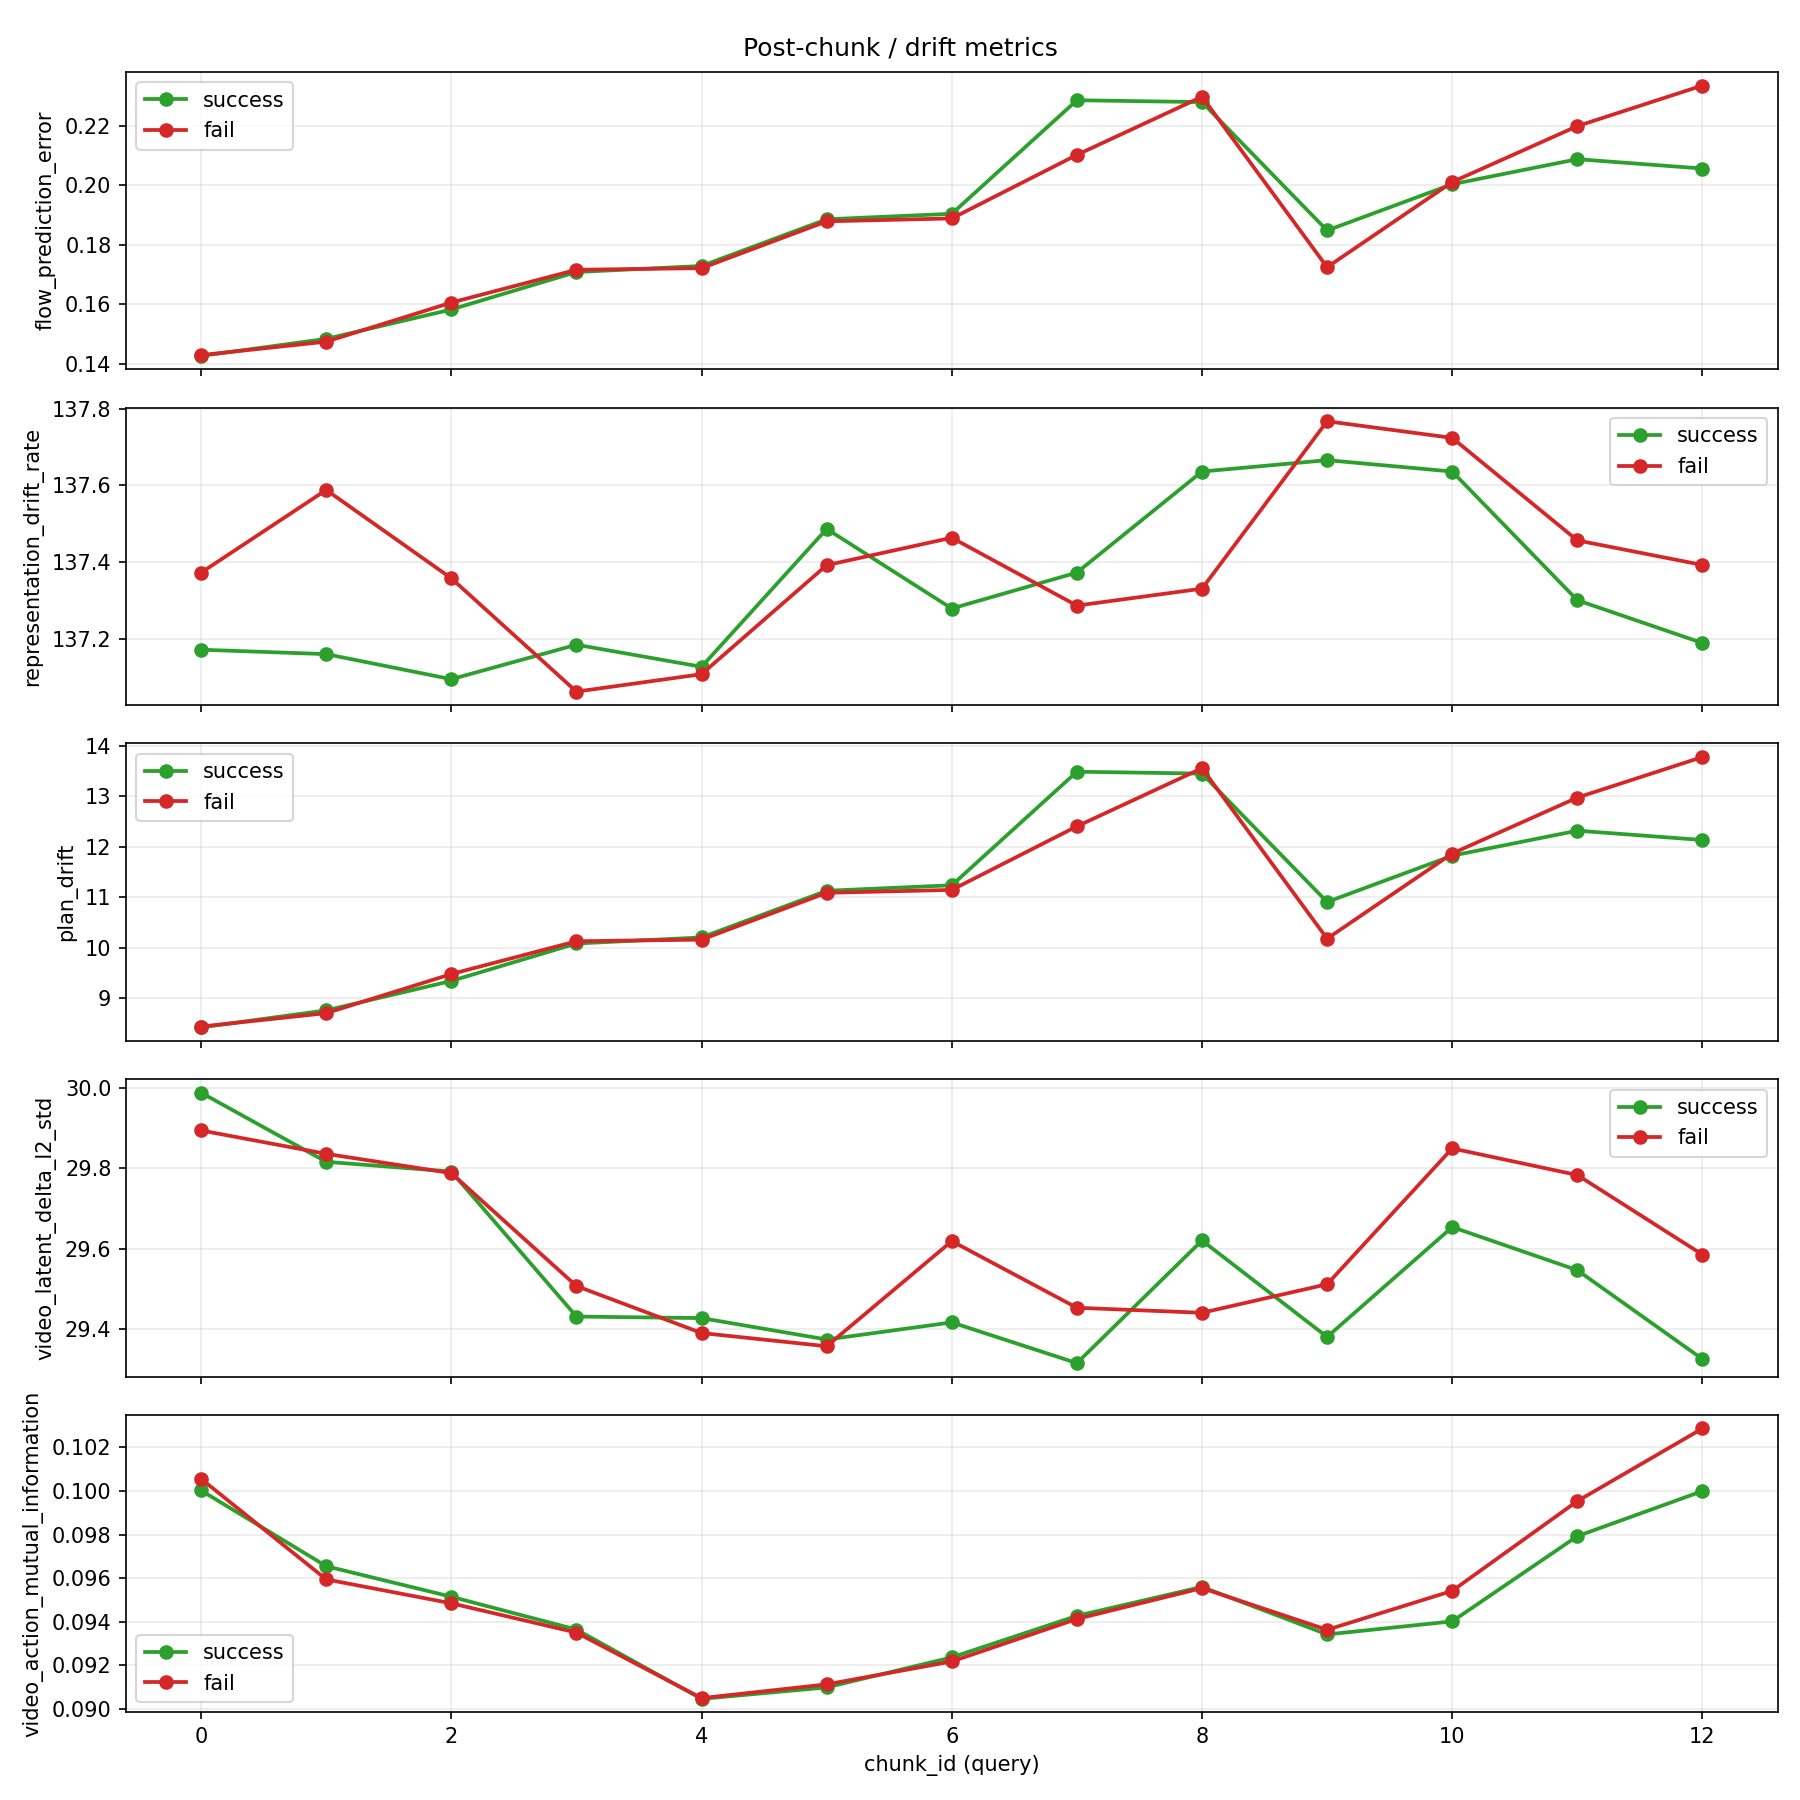

### Episode-level metric separation

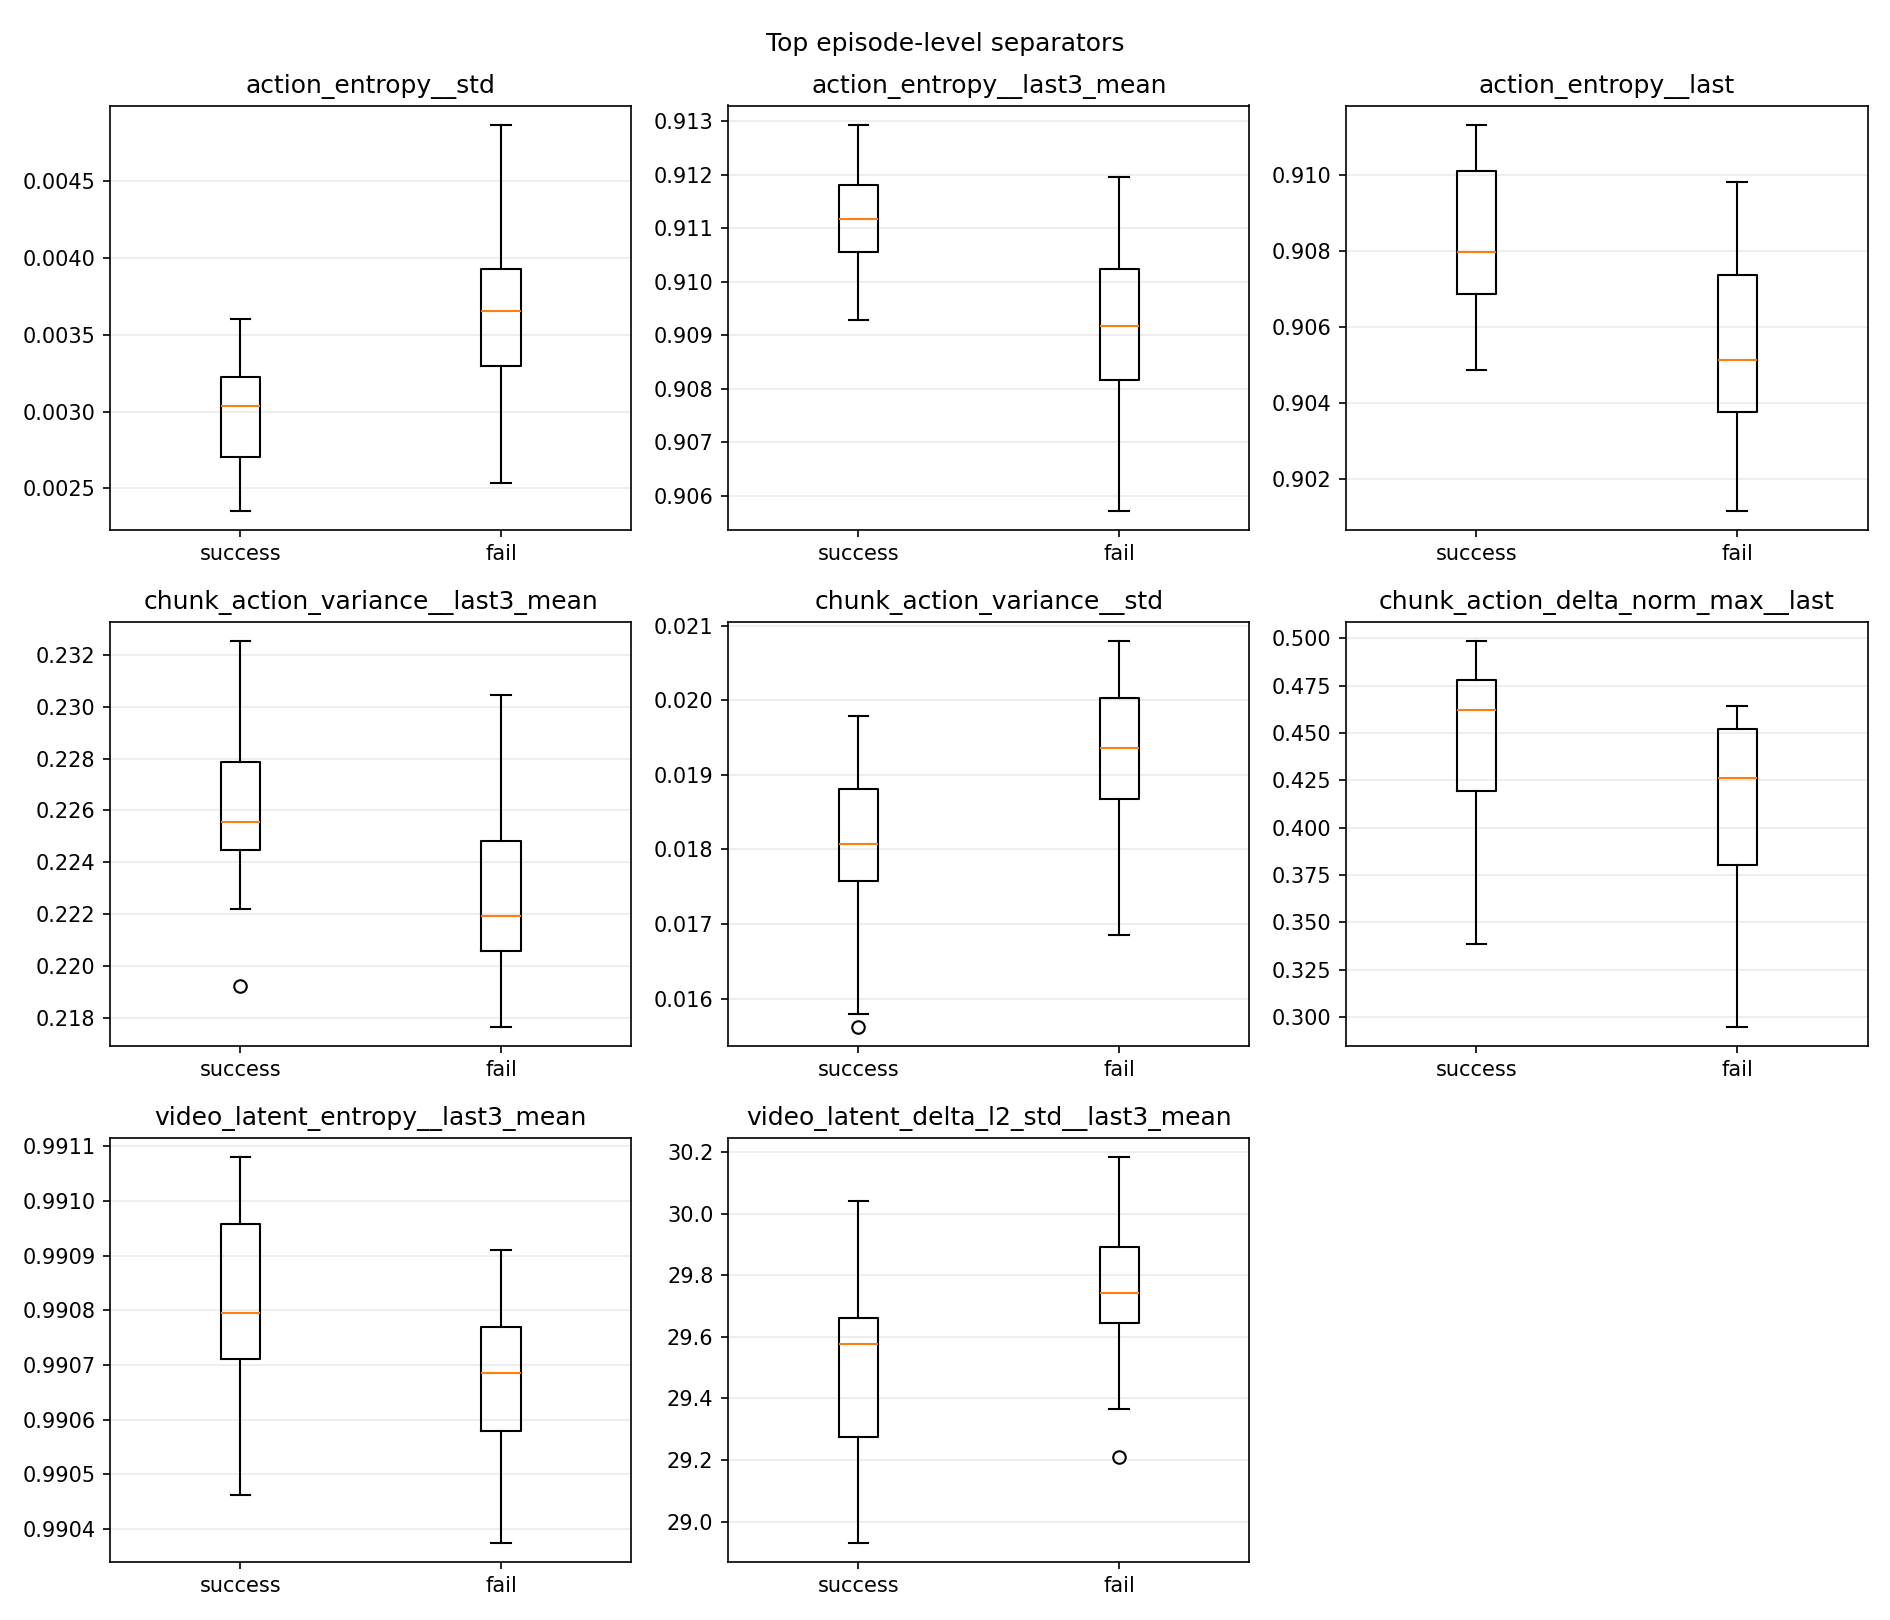

### Query-level fail-prediction AUC

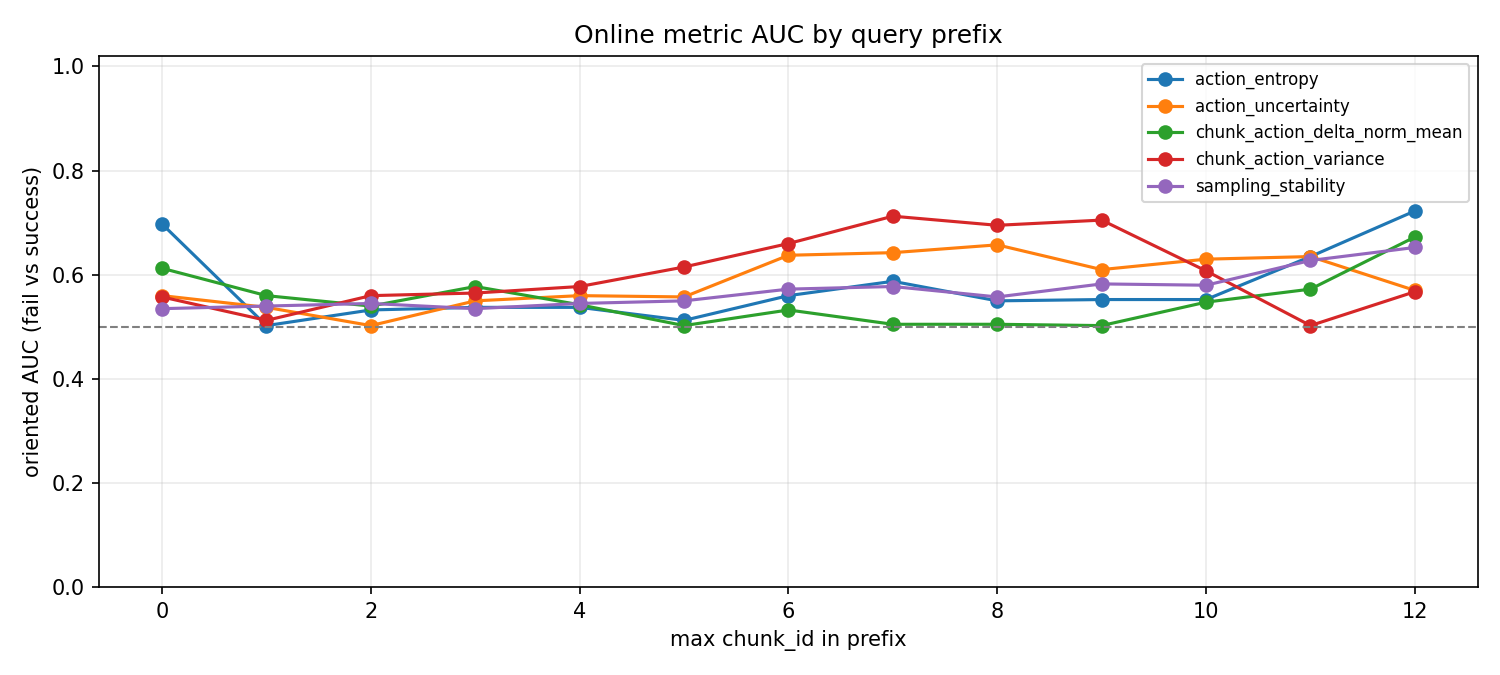

### Risk: high uncertainty

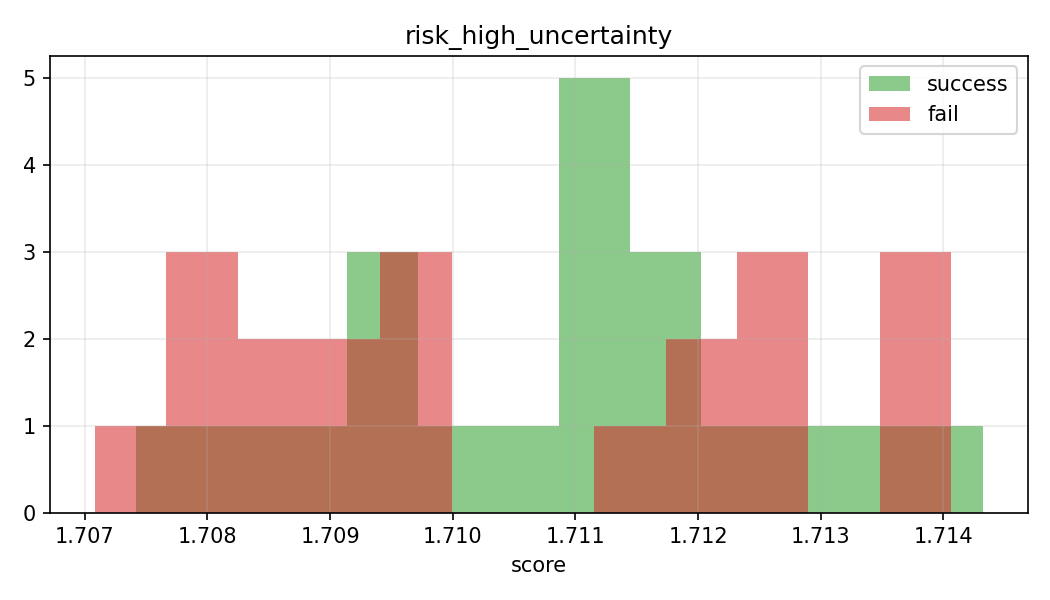

### Risk: overconfidence latent

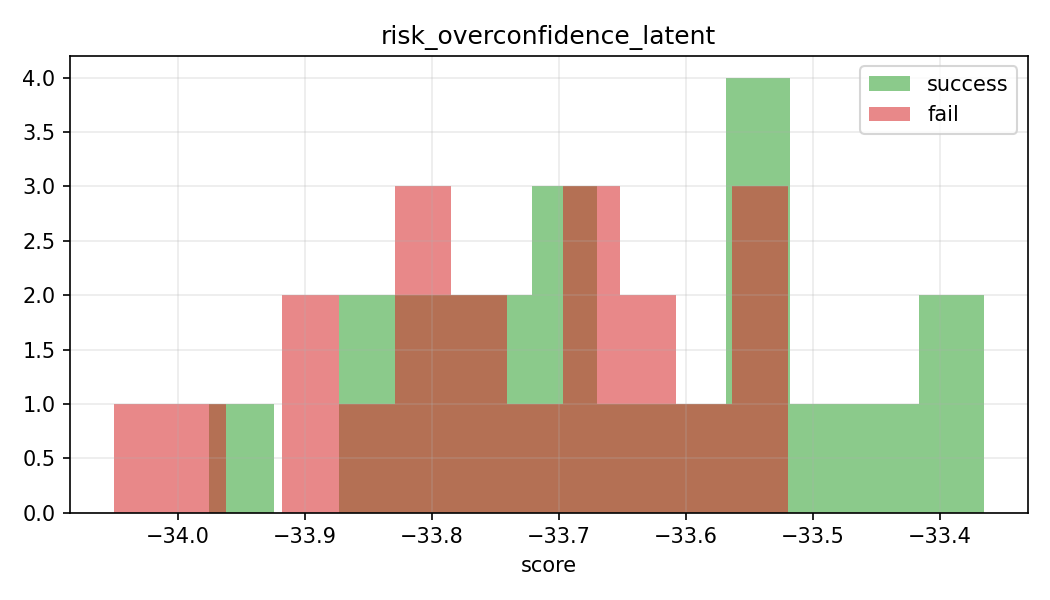

### Risk: overconfidence action

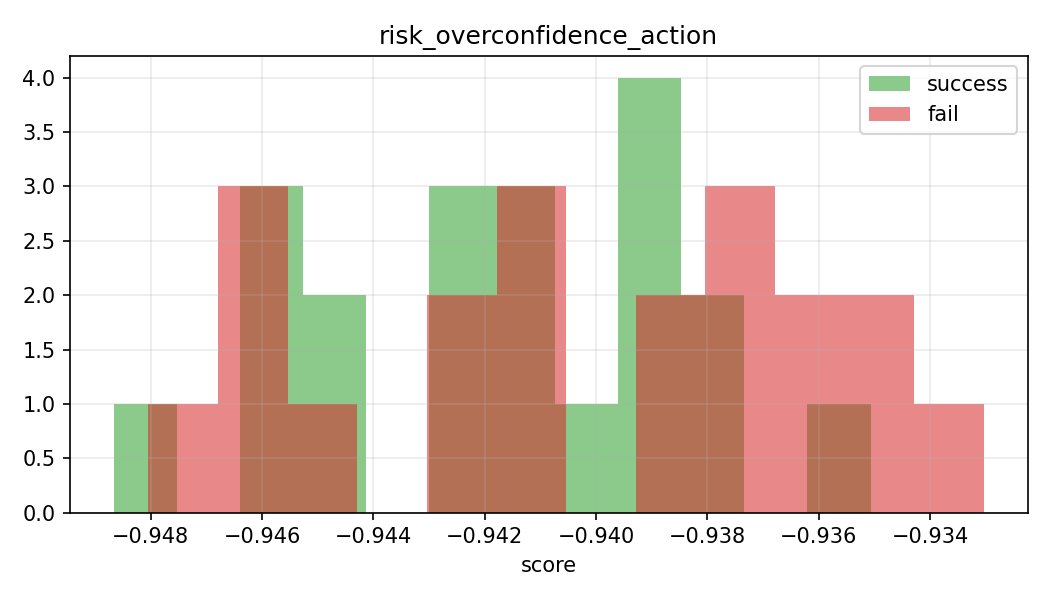

In [7]:
for title, fname in [
    ("Query-level uncertainty metrics", "uncertainty_query_timeseries.png"),
    ("Post-chunk / drift metrics", "prediction_error_query_timeseries.png"),
    ("Episode-level metric separation", "episode_metric_boxplots.png"),
    ("Query-level fail-prediction AUC", "online_metric_auc_by_query.png"),
    ("Risk: high uncertainty", "risk_high_uncertainty_hist.png"),
    ("Risk: overconfidence latent", "risk_overconfidence_latent_hist.png"),
    ("Risk: overconfidence action", "risk_overconfidence_action_hist.png"),
]:
    path = ANALYSIS_DIR / fname
    if path.exists():
        display(Markdown(f"### {title}"))
        display(Image(filename=str(path)))
    else:
        print("missing:", path)

## 3. Краткий вывод

Сравниваем с ysda:
- там boundary был на `libero_spatial_with_milk / task5 / init0` с Cosmos Policy uncertainty/value метриками;
- здесь boundary на `libero_spatial / task0 / init9` с mimic-video chunk diagnostics.

Если `risk_overconfidence_latent` / `risk_overconfidence_action` дают AUC > 0.7, а `risk_high_uncertainty` — нет, это похоже на overconfident-failure паттерн из ysda notebook.

## 4. CatBoost: обучение и `catboost_select` (3 кандидата)

Обучаем chunk-classifier на **baseline** boundary-метриках (40 rollout, split 28/12 по `rollout_id`), затем прогоняем ту же задачу/init с:
- `regen_strategy=catboost_select`, `regen_num_candidates=3`
- выбор кандидата с **минимальной** P(failure) из CatBoost
- `max_control_steps=120` (6 сек)
- все видео сохраняются

In [9]:
import subprocess

TRAIN_CATBOOST = False  # уже обучено
RUN_CATBOOST_EVAL = False  # eval уже завершён

if TRAIN_CATBOOST:
    subprocess.run(
        [sys.executable, str(REPO_ROOT / "scripts/training/train_boundary_catboost.py")],
        check=True,
        cwd=str(REPO_ROOT),
    )
    display(Markdown(f"Модель: `{CATBOOST_ARTIFACTS / 'catboost_chunk_regen.cbm'}`"))

if RUN_CATBOOST_EVAL:
    subprocess.run(
        ["bash", str(REPO_ROOT / "scripts/eval/launch_boundary_catboost_select_3gpu.sh")],
        check=True,
        cwd=str(REPO_ROOT),
        env={**os.environ, "OUT_DIR": str(CATBOOST_OUT.relative_to(REPO_ROOT))},
    )
    print("tmux: mimic_boundary_catboost_select3 | GPUs 3,4,6")
else:
    print("CatBoost metrics:", CATBOOST_METRICS / "episode_traces.jsonl")
    print("exists:", (CATBOOST_METRICS / "episode_traces.jsonl").exists() or bool(list(CATBOOST_METRICS.glob("rank*"))))

{
  "threshold": 0.5,
  "roc_auc": 0.5853658536585366,
  "average_precision": 0.609180808166753,
  "accuracy": 0.5955056179775281,
  "precision_failure": 0.603448275862069,
  "recall_failure": 0.7291666666666666,
  "f1_failure": 0.660377358490566,
  "tn": 54,
  "fp": 69,
  "fn": 39,
  "tp": 105,
  "train_chunks": 580,
  "val_chunks": 267,
  "train_rollouts": 28,
  "val_rollouts": 12,
  "train_episode_success_rate": 0.5,
  "val_episode_success_rate": 0.5
}
Model: /home/motovilovil/Robotics/robotics_project/mimic-video/artifacts/libero_spatial/boundary_task0_init9/catboost_chunk_regen.cbm


Модель: `/home/motovilovil/Robotics/robotics_project/mimic-video/artifacts/libero_spatial/boundary_task0_init9/catboost_chunk_regen.cbm`

Пропуск eval (уже запущен или завершён).
metrics: True [PosixPath('/home/motovilovil/Robotics/robotics_project/mimic-video/eval_outputs/libero_spatial/boundary_runs/task0_init9_catboost_select3_6sec/metrics/rank1'), PosixPath('/home/motovilovil/Robotics/robotics_project/mimic-video/eval_outputs/libero_spatial/boundary_runs/task0_init9_catboost_select3_6sec/metrics/rank2'), PosixPath('/home/motovilovil/Robotics/robotics_project/mimic-video/eval_outputs/libero_spatial/boundary_runs/task0_init9_catboost_select3_6sec/metrics/rank0')]


## 5. Сравнение baseline vs catboost_select3

Парное сравнение по одинаковым `rollout_seed`. Baseline: `max_control_steps=220`, метрики обрезаны до 6с; catboost: лимит 6с в среде.

In [10]:
import importlib
import boundary_report
importlib.reload(boundary_report)
from boundary_report import compare_boundary_runs, merge_rank_metrics, run_full_analysis

if "results" not in globals():
    if list(METRICS_DIR.glob("rank[0-9]*")):
        merge_rank_metrics(METRICS_DIR, world_size=WORLD_SIZE)
    results = run_full_analysis(METRICS_DIR, ANALYSIS_DIR)

if list(CATBOOST_METRICS.glob("rank[0-9]*")):
    merge_rank_metrics(CATBOOST_METRICS, world_size=WORLD_SIZE)

catboost_results = run_full_analysis(CATBOOST_METRICS, CATBOOST_ANALYSIS)
cmp = compare_boundary_runs(
    METRICS_DIR,
    CATBOOST_METRICS,
    COMPARE_ANALYSIS,
    baseline_label="baseline_220",
    strategy_label="catboost_select3_120",
)

display(Markdown("### Baseline (none, 220 steps)"))
display(pd.DataFrame([results["summary"]]))

display(Markdown("### CatBoost select-3 (120 steps)"))
display(pd.DataFrame([catboost_results["summary"]]))

display(Markdown("### Paired comparison"))
display(pd.DataFrame([cmp["summary"]]))
display(cmp["paired"].head(12))

ImportError: cannot import name 'compare_boundary_runs' from 'boundary_report' (/home/motovilovil/Robotics/robotics_project/mimic-video/scripts/analysis/boundary_report.py)

In [11]:
for title, path in [
    ("SR comparison", COMPARE_ANALYSIS / "baseline_vs_strategy_sr.png"),
    ("CatBoost: query-level metrics", CATBOOST_ANALYSIS / "uncertainty_query_timeseries.png"),
    ("CatBoost: episode separators", CATBOOST_ANALYSIS / "episode_metric_boxplots.png"),
    ("CatBoost: risk scores", CATBOOST_ANALYSIS / "risk_overconfidence_latent_hist.png"),
]:
    if path.exists():
        display(Markdown(f"### {title}"))
        display(Image(filename=str(path)))
    else:
        print("missing:", path)

missing: /home/motovilovil/Robotics/robotics_project/mimic-video/eval_outputs/libero_spatial/boundary_runs/task0_init9_catboost_select3_6sec/metrics/comparison/baseline_vs_strategy_sr.png
missing: /home/motovilovil/Robotics/robotics_project/mimic-video/eval_outputs/libero_spatial/boundary_runs/task0_init9_catboost_select3_6sec/metrics/analysis/uncertainty_query_timeseries.png
missing: /home/motovilovil/Robotics/robotics_project/mimic-video/eval_outputs/libero_spatial/boundary_runs/task0_init9_catboost_select3_6sec/metrics/analysis/episode_metric_boxplots.png
missing: /home/motovilovil/Robotics/robotics_project/mimic-video/eval_outputs/libero_spatial/boundary_runs/task0_init9_catboost_select3_6sec/metrics/analysis/risk_overconfidence_latent_hist.png
